# <center>Đồ án 3: Linear Regression</center>

# Thông tin sinh viên

- Họ và tên: Nguyễn Văn Lê Bá Thành
- MSSV: 22127390
- Lớp: 22CLC08

# Import

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.inspection import PartialDependenceDisplay

# Import thêm dữ thư viện nếu cần

# Đọc dữ liệu

In [32]:
# Đọc dữ liệu bằng pandas
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

# Lấy các đặc trưng X và giá trị mục tiêu y cho các tập huấn luyện (train) và kiểm tra (test)
X_train = train.iloc[:, :-1]    # Dataframe (chứa 5 đặc trưng huấn luyện)
y_train = train.iloc[:, -1]     # Series    (chứa 1 giá trị mục tiêu huấn luyện)

X_test = test.iloc[:, :-1]      # Dataframe (chứa 5 đặc trưng kiểm tra)
y_test = test.iloc[:, -1]       # Series    (chứa 1 giá trị mục tiêu kiểm tra)

# Sinh viên có thể sử dụng các khác nếu cần

# Cài đặt hàm

In [33]:
# Cài đặt các hàm cần thiết ở đây

def preprocess(X):
    ''' 
    This function preprocesses the input data by adding a column of ones and interaction terms.

    Parameters
    ----------
    X : np.array
        Input data
    
    Returns
    -------
    X : np.array
        Preprocessed input data with interaction terms
    '''
    X_new = np.hstack((np.ones((X.shape[0], 1)), X))
    return X_new

class OLSLinearRegression:
    def fit(self, X, y):
        ''' 
        Fit the model to the data using Ordinary Least Squares.

        Parameters
        ----------
        X : np.array
            Input data
        y : np.array
            Output data

        Returns
        -------
        self : object
            Returns the instance of the class
        '''
        X_pinv = np.linalg.pinv(X)
        self.w = X_pinv @ y
        return self

    def get_params(self):
        ''' 
        Get the parameters of the model.

        Returns
        -------
        self.w : np.array
            Optimal parameters (column vector)
        '''
        return self.w   

    def predict(self, X):
        ''' 
        Predict the output of the model.

        Parameters
        ----------
        X : np.array
            Input data

        Returns
        -------
        X @ self.w : np.array
            Predicted output
        '''
        return X @ self.w

def mae(y, y_hat):
    ''' 
    Calculate the mean absolute error (MAE).

    Parameters
    ----------
    y : np.array
        Actual output data
    y_hat : np.array
        Predicted output data

    Returns
    -------
    np.mean(np.abs(y - y_hat)) : float
        Mean absolute error
    '''
    return np.mean(np.abs(y.ravel() - y_hat.ravel()))

class k_folds_cross_validation:
    def __init__(self, k, features, models, data):
        ''' 
        Assign parameters to self

        Parameters
        ----------
        k : int
            Number of fold
        features : list[str]
            List contain all features excluding targer feature
        models : list[list[str]]
            An matrix that contain all model
        data : DataFrame
            DataFrame contain data from .csv files

        Returns
        -------
        None
        '''
        self.k = k
        self.features = features
        self.models = models
        self.data = data

    def shuffle_data(self):
        ''' 
        Shuffle the DataFrame

        Parameters
        ----------
        None

        Returns
        -------
        None
        '''
        np.random.seed(42)
        data_arr = self.data.values
        np.random.shuffle(data_arr)
        self.data_shuffled = pd.DataFrame(data_arr, columns=self.data.columns)

    def split_to_k_folds(self):
        ''' 
        Split the DataFrame to k folds

        Parameters
        ----------
        None

        Returns
        -------
        None
        '''
        rows = self.data_shuffled.shape[0]
        self.folds = [self.data_shuffled[i*(rows//self.k): (i+1)*(rows//self.k)] for i in range(self.k)]
        
    def create_interaction_terms(self, data, model):
        ''' 
        Split the DataFrame to k folds

        Parameters
        ----------
        data : DataFrame
            DataFrame need to add interaction terms

        model : list[str]
            List of feature (may contain interaction terms)

        Returns
        -------
        data : DataFrame
            DataFrame after add interaction terms
        '''
        for feature in model:
            if " x " in feature:
                features_to_multiply = feature.split(" x ")
                data[feature] = data[features_to_multiply[0]] * data[features_to_multiply[1]]
            if " + " in feature:
                features_to_multiply = feature.split(" + ")
                data[feature] = data[features_to_multiply[0]] + data[features_to_multiply[1]]
        return data

    def cross_validation(self):
        ''' 
        Peform cross validation

        Parameters
        ----------
        None

        Returns
        -------
        None
        '''
        self.maes_list = []
        for model in self.models: # Loop through all model
            mae_for_each_model = []
            for i in range(self.k): # Loop through all fold
                fold = self.folds[i]
                
                # Create interaction terms for test data
                fold = self.create_interaction_terms(fold.copy(), model)
                
                # Separate test data with ith fold
                X_test_2b = fold.loc[:, model].to_numpy().reshape(-1, len(model))
                y_test_2b = fold.iloc[:, -1]
                
                # Get training data excluding the current fold and create interaction terms
                training_folds = self.folds[:i] + self.folds[i+1:]
                train_data = pd.concat(training_folds)
                train_data = self.create_interaction_terms(train_data.copy(), model)
                
                # Separate train data from train_data
                X_train_2b = train_data.loc[:, model].to_numpy().reshape(-1, len(model))
                y_train_2b = train_data.iloc[:, -1]
                
                # Perform data fitting
                current_model = OLSLinearRegression().fit(preprocess(X_train_2b), y_train_2b)

                # Predict target feature
                y_pred = current_model.predict(preprocess(X_test_2b))
                
                # Calculate mae for current fold
                current_mae = mae(y=y_test_2b, y_hat=y_pred)
                mae_for_each_model.append(current_mae)
                
            self.maes_list.append(mae_for_each_model)
        # Calculate mae for each model
        self.maes_list = np.mean(np.array(self.maes_list), axis=1)  
        
    def best_model(self):
        ''' 
        Return the average MAE for each model after cross-validation and identify the best model.

        Parameters
        ----------
        None

        Returns
        -------
        maes_list : list[double]
            list contains mae for each model

        best_feature_index : int
            Index of best feature
        '''
        maes_list = self.maes_list
        best_feature_index = np.argmin(self.maes_list) 
        return maes_list, best_feature_index

*Chú thích: Cần có docstrings cho các hàm.*

# Yêu cầu 1: Phân tích khám phá dữ liệu (1 điểm)

## Kiểm tra dữ liệu đầu vào

In [34]:
# Phân tích khám phá dữ liệu thông qua thống kê và các biểu đồ
# Chỉ được phân tích trên tập huấn luyện
train.describe().T

# see precentege of missing value in each column

train.isna().sum() / train.shape[0]

# see column data type and some info

train.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     9000 non-null   int64  
 1   Previous Scores                   9000 non-null   int64  
 2   Extracurricular Activities        9000 non-null   int64  
 3   Sleep Hours                       9000 non-null   int64  
 4   Sample Question Papers Practiced  9000 non-null   int64  
 5   Performance Index                 9000 non-null   float64
dtypes: float64(1), int64(5)
memory usage: 422.0 KB


## Phân tích đơn biến và mô hình hoá

In [35]:
# create function to visualized categorical column using count plot

def count_plot(column_name, hue = None, rotation = 0):
    """
    1) input : column name, column data type must be object or categorical
    3) output : cout plot using seaborn modules, unique values in x-axis and frequency in y-axis
    4) i use bar_label to show frequency of each unique values above each column in graph
    """
    graph = sns.countplot(x = column_name, data = train, hue = hue, order = train[column_name].value_counts().index)
    for container in graph.containers:
        graph.bar_label(container)
        
        
    plt.xticks(rotation = rotation)
    plt.show()

In [36]:
# create function that visualized numeric columns using box plot

def box_plot(x_axis = None, y_axis = None, hue = None, col = None):
    """
    input : x_axis, y_axis and hue column, column data type must be numeric in y_axis
    output : box plot to see distribution of column values such as min,max,mean,medien,std
    """
    sns.catplot(x = x_axis, y = y_axis, data = train, hue = hue, kind = "box", col = col)
    plt.xlabel(x_axis)
    plt.ylabel(y_axis)
    plt.show()

## Khám phá cột Hours Studied

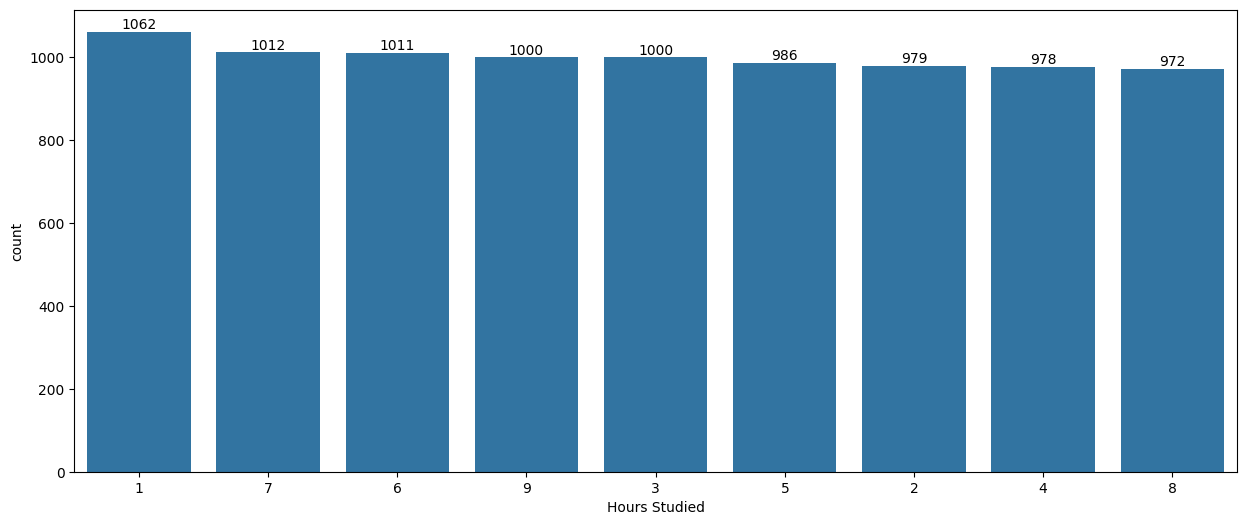

In [37]:
# number of unique values is relatively large, count plot more suitable for it

# first set figure size
plt.figure(figsize = (15,6))

# call function i create it in cell 10
count_plot(column_name = "Hours Studied") 

**Dựa vào biểu đồ ta có thể thấy**
* Hầu hết học sinh có số giờ học là 1

## Khám phá cột Previous Scores

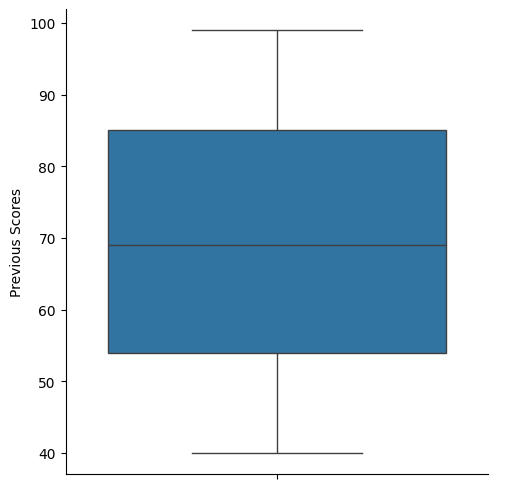

In [38]:
# see distribution 

box_plot(y_axis = "Previous Scores") # call function i create it in cell 11

**Dựa vào biểu đồ ta có thể thấy**
* 50% sinh viên có điểm trên 65 điểm
* Không có sinh viên nào đạt điểm tối đa

## Khám phá cột Extracurricular Activities

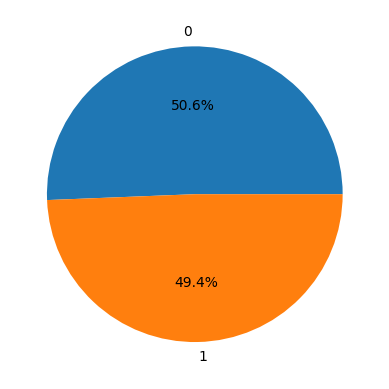

In [39]:
# output number of values count

plt.pie(train["Extracurricular Activities"].value_counts(), labels = train["Extracurricular Activities"].value_counts().index, autopct = "%1.1f%%")
plt.show()

**Dựa vào biểu đồ ta có thể thấy**
* Sinh viên có xu hướng không tham gia vào các hoạt động ngoại khoá

## Khám phá cột Sleep Hours

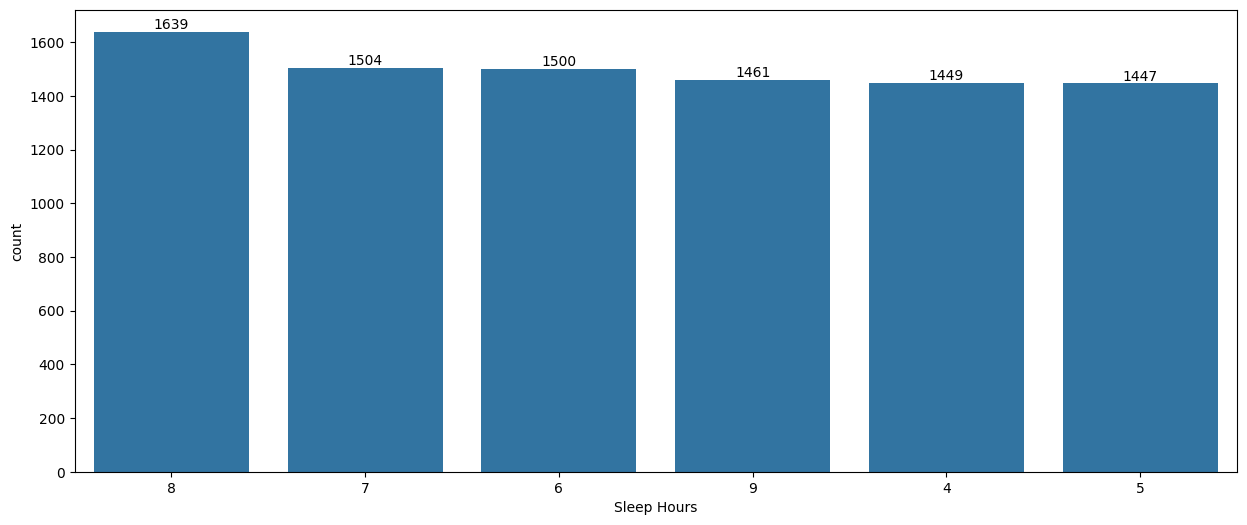

In [40]:
# number of unique values is relatively large, count plot more suitable for it

# first set figure size
plt.figure(figsize = (15,6))

# call function i create it in cell 10
count_plot(column_name = "Sleep Hours")

**Dựa vào biểu đồ ta có thể thấy**
* Hầu hết học sinh ngủ 8 tiếng

## Khám phá cột Sample Question Papers Practiced

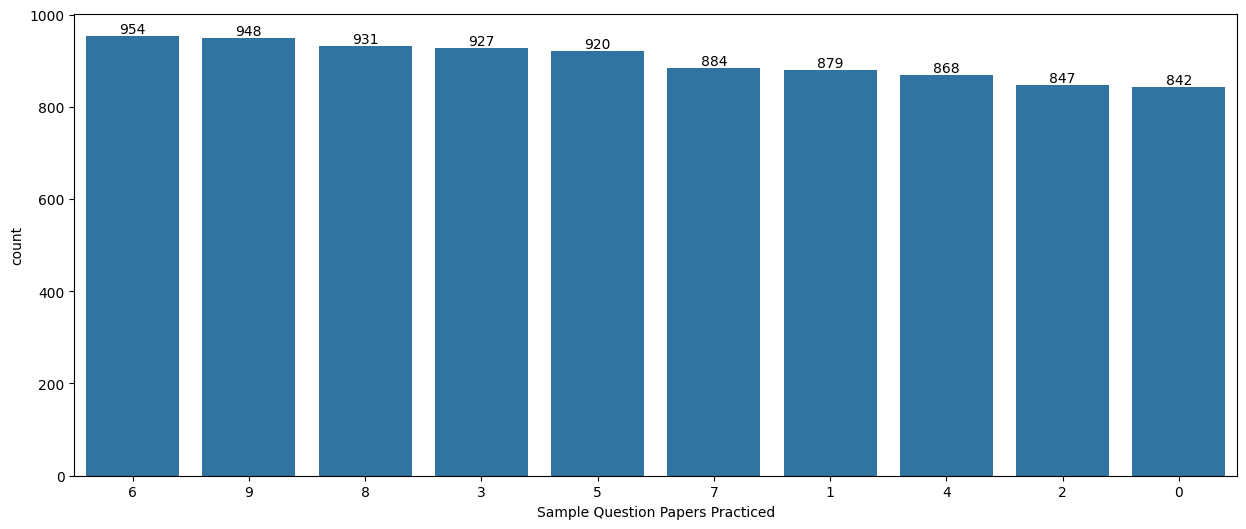

In [41]:
# number of unique values is relatively large, count plot more suitable for it

# first set figure size
plt.figure(figsize = (15,6))

# call function i create it in cell 10
count_plot(column_name = "Sample Question Papers Practiced")

**Dựa vào biểu đồ ta có thể thấy**
* Có những học sinh không làm bài mẫu nào

## Phân tích hai biến và mô hình hoá

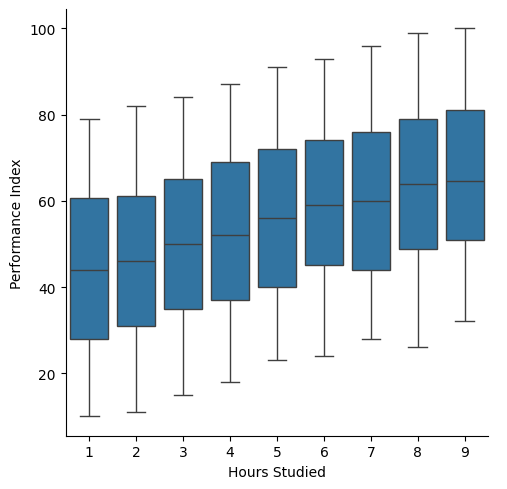

In [42]:
# What is "Hours Studied" and "Performance Index" distribution

box_plot(x_axis = "Hours Studied", y_axis = "Performance Index") # call function i create it in cell 11

**Dựa vào biểu đồ ta có thể thấy**
* Thời gian học càng cao thì điểm càng cao

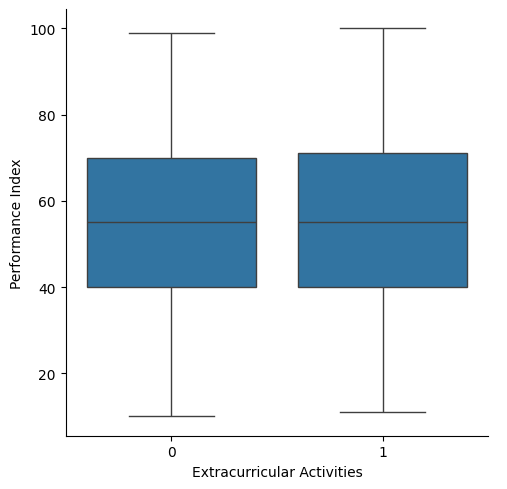

In [43]:
# What is "	Extracurricular Activities" and "Performance Index" distribution

box_plot(x_axis = "Extracurricular Activities", y_axis = "Performance Index") # call function i create it in cell 11

**Dựa vào biểu đồ ta có thể thấy**
* Tham gia vào các hoạt động ngoại khoá đóng góp rất ít vào việc đạt điểm cao

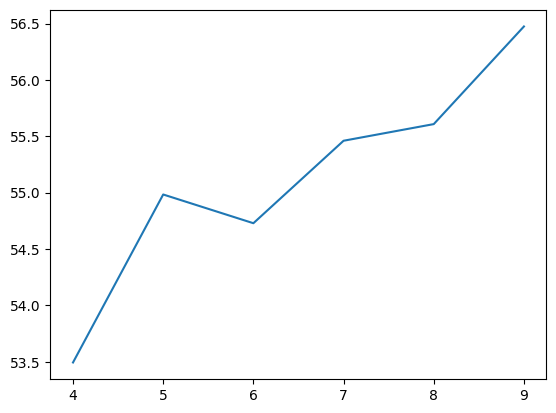

In [44]:
# What is "Extracurricular Activities" and "Performance Index" distribution

avg_performance_by_hours = train.groupby('Sleep Hours')['Performance Index'].mean()
plt.plot(avg_performance_by_hours.index, avg_performance_by_hours.values)
plt.show()

**Dựa vào biểu đồ ta có thể thấy**
* Thời gian ngủ càng nhiều, điểm càng cao

## Biểu đồ nhiệt về sự tương quan

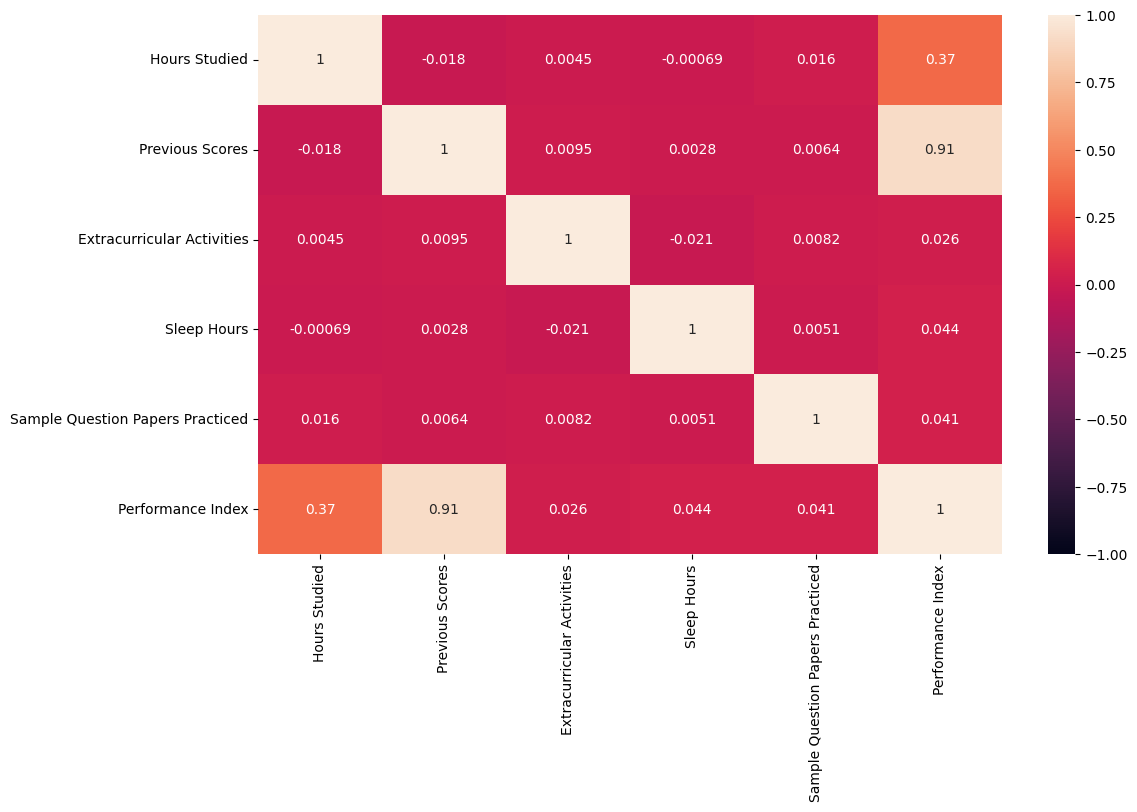

In [45]:
plt.figure(figsize=(12, 7))
sns.heatmap(train.corr(), annot = True, vmin = -1, vmax = 1)
plt.show()

**Dựa vào biểu đồ ta có thể thấy**
* Có rất nhiều tương quan dương giữa đặc trưng Performance Index với các đặc trưng khác

# Yêu cầu 2a: Xây dựng mô hình sử dụng toàn bộ 5 đặc trưng đề bài cung cấp (2 điểm) 

In [46]:
# Phần code cho yêu cầu 2a
features_2a = ['Hours Studied', 'Previous Scores', 'Extracurricular Activities', 'Sleep Hours', 'Sample Question Papers Practiced']
X_train_2a = preprocess(X_train)
y_train_2a = y_train

# Perform data fitting on 5 feature
model_2a = OLSLinearRegression().fit(X_train_2a, y_train_2a)

# Get coefficent of each feature after fitting
params_2a = model_2a.get_params()
print(f"Coefficent: {params_2a[0]}")
for i in range(1, len(params_2a)):

    print(f"{features_2a[i-1]}: {params_2a[i]}")

# Perform prediction on test set
y_hat_2a = model_2a.predict(preprocess(X_test))

Coefficent: -33.969283681777966
Hours Studied: 2.8520200719076696
Previous Scores: 1.017869573837324
Extracurricular Activities: 0.6042817401240166
Sleep Hours: 0.47356583475389935
Sample Question Papers Practiced: 0.19237624280205454


In [47]:
# Gọi hàm MAE (tự cài đặt hoặc từ thư viện) trên tập kiểm tra
mae = mae(y=y_test, y_hat=y_hat_2a)
print("Độ lỗi tuyệt đối trung bình (MAE - Mean Absolute Error) của mô hình ở câu 1a: ",mae)

Độ lỗi tuyệt đối trung bình (MAE - Mean Absolute Error) của mô hình ở câu 1a:  1.5956486884762948


C:\Users\CISTILY\AppData\Local\Temp\ipykernel_50360\896876167.py:84: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  return np.mean(np.abs(y.ravel() - y_hat.ravel()))


Công thức hồi quy, phần trọng số làm tròn đến 3 chữ số thập phân, ví dụ 0.012345 $\to$ 0.012

$$\text{Student Performance} = 2.852 \times \text{Hours Studied} + 1.018 \times \text{Previous Scores} + 0.604 \times \text{Extracurricular Activities} + 0.474 \times \text{Sleep Hours} + 0.192 \times \text{Sample Question Papers Practiced}.$$

# Yêu cầu 2b: Xây dựng mô hình sử dụng duy nhất 1 đặc trưng, tìm mô hình cho kết quả tốt nhất (2 điểm)

Lưu ý: Khi sử dụng cross-validation, sinh viên cần xáo trộn dữ liệu 1 lần duy nhất và thực hiện trên toàn bộ đặc trưng

In [48]:
# Phần code cho yêu cầu 2b
# Tìm ra đặc trưng tốt nhất (trong 5 đặc trưng)
# In ra các kết quả cross-validation như yêu cầu
features_2b = ['Hours Studied', 'Previous Scores', 'Extracurricular Activities', 'Sleep Hours', 'Sample Question Papers Practiced']
models_2b = [['Hours Studied'], ['Previous Scores'], ['Extracurricular Activities'], ['Sleep Hours'], ['Sample Question Papers Practiced']]
kfcv_er_1b = k_folds_cross_validation(k=5, features=features_2b, models=models_2b, data=train)
kfcv_er_1b.shuffle_data()
kfcv_er_1b.split_to_k_folds()
kfcv_er_1b.cross_validation()
avg_mae_of_each_model, index_best_feature = kfcv_er_1b.best_model()
for i in range(avg_mae_of_each_model.shape[0]):
    print(f"Mae cho mô hình với đặc trưng {features_2b[i]} từ k-fold Cross Validation (lấy trung bình): {avg_mae_of_each_model[i]}")
print(f"Mô hình tốt nhất là mô hình với feature: {features_2b[index_best_feature]}")

TypeError: 'numpy.float64' object is not callable

In [ ]:
# Huấn luyện lại mô hình best_feature_model với đặc trưng tốt nhất trên toàn bộ tập huấn luyện
best_feature_model = features_2b[index_best_feature]

X_train_2b = train.loc[:, best_feature_model].to_numpy().reshape(-1, 1)
y_train_2b = train.iloc[:, -1]
X_test_2b = test.loc[:, best_feature_model].to_numpy().reshape(-1, 1)
y_test_2b = test.iloc[:, -1]

# Perform data fitting on the best feature
model_2b = OLSLinearRegression().fit(preprocess(X_train_2b), y_train_2b)

# Get coefficent of each feature after fitting
params_2b = model_2b.get_params()
print(f"Intercept: {params_2b[0]}")
print(f"{best_feature_model}: {params_2b[1]}")

# Perform prediction on test set
y_hat_2b = model_2b.predict(preprocess(X_test_2b))

Intercept: -14.988645779326669
Previous Scores: 1.0105030093167855


In [ ]:
# Gọi hàm MAE (tự cài đặt hoặc từ thư viện) trên tập kiểm tra với mô hình best_feature_model
mae = mae(y=y_test_2b, y_hat=y_hat_2b)
print("Độ lỗi tuyệt đối trung bình (MAE - Mean Absolute Error) của mô hình ở câu 1a: ",mae)

Độ lỗi tuyệt đối trung bình (MAE - Mean Absolute Error) của mô hình ở câu 1a:  6.544277293452511


C:\Users\admin\AppData\Local\Temp\ipykernel_8212\1005125032.py:84: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  return np.mean(np.abs(y.ravel() - y_hat.ravel()))


Công thức hồi quy (dựa trên mô hình đặc trưng tốt nhất), phần trọng số làm tròn đến 3 chữ số thập phân, ví dụ 0.012345 $\to$ 0.012

$$\text{Student Performance} = -14.989 + 1.011 \times \text{Previous Scores}$$

# Yêu cầu 2c: Sinh viên tự xây dựng/thiết kế mô hình, tìm mô hình cho kết quả tốt nhất (2 điểm)

## Xây dựng/Thiết kế mô hình

In [ ]:
# Trình bày toàn bộ code liên quan đến việc thiết kế mô hình

# Calculate the correlation matrix
correlation_matrix = train.corr()

# Extract the correlation of each feature with the target variable (Performance Index)
correlation_with_target = correlation_matrix["Performance Index"].sort_values(ascending=False)

correlation_with_target

Performance Index                   1.000000
Previous Scores                     0.914775
Hours Studied                       0.369148
Sleep Hours                         0.043980
Sample Question Papers Practiced    0.041088
Extracurricular Activities          0.025637
Name: Performance Index, dtype: float64

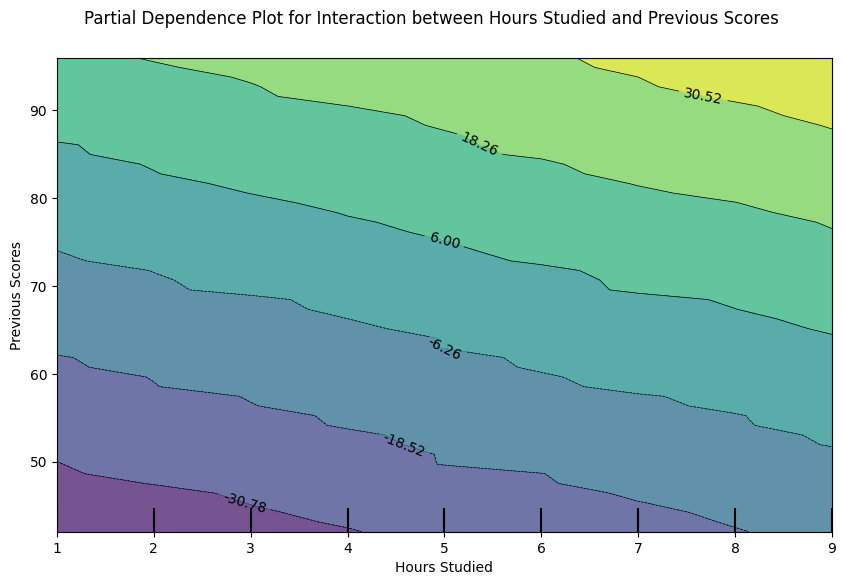

In [ ]:
X = train.iloc[:, [0, 1]]
y = train['Performance Index']

# Train Gradient Boosting Model
model = GradientBoostingRegressor(n_estimators=100, max_depth=3, random_state=42)
model.fit(X, y)

fig, ax = plt.subplots(figsize=(10, 6))
pdp_display = PartialDependenceDisplay.from_estimator(
    model, 
    X, 
    features=[(0, 1)],  # Feature indices for "Hours Studied" and "Previous Scores"
    grid_resolution=50,
    ax=ax
)
plt.suptitle('Partial Dependence Plot for Interaction between Hours Studied and Previous Scores')
plt.subplots_adjust(top=0.9)  # Adjust title position
plt.show()

In [ ]:
# Get top most
model_1 = ["Hours Studied", "Previous Scores"]
model_2 = ["Hours Studied", "Previous Scores", "Hours Studied + Previous Scores"]
model_3 = ["Hours Studied x Hours Studied", "Previous Scores x Previous Scores"]

## Tìm mô hình cho kết quả tốt nhất

Lưu ý: Khi sử dụng cross-validation, sinh viên cần xáo trộn dữ liệu 1 lần duy nhất và thực hiện trên toàn bộ $m$ mô hình mà sinh viên thiết kế

In [ ]:
# Phần code cho yêu cầu 2c
# Tìm ra mô hình tốt nhất (trong m mô hình mà sinh viên tự thiết kế)
# In ra các kết quả cross-validation như yêu cầu
features_1d = train.columns.to_list()
models_1d = [model_1, model_2, model_3]
kfcv_er_1d = k_folds_cross_validation(k=5, features=features_1d,models=models_1d ,data=train)
kfcv_er_1d.shuffle_data()
kfcv_er_1d.split_to_k_folds()
kfcv_er_1d.cross_validation()

avg_mae_of_each_model, index_best_feature = kfcv_er_1d.best_model()
for i in range(avg_mae_of_each_model.shape[0]):
    print(f"Mae cho mô hình thứ {i + 1} từ k-fold Cross Validation (lấy trung bình): {avg_mae_of_each_model[i]:.20f}")
print(f"Mô hình tốt nhất là mô hình thứ {index_best_feature+1}")

      Hours Studied  Previous Scores  Extracurricular Activities  Sleep Hours  \
1800            4.0             59.0                         1.0          9.0   
1801            8.0             42.0                         0.0          8.0   
1802            2.0             58.0                         1.0          4.0   
1803            2.0             54.0                         0.0          5.0   
1804            7.0             42.0                         1.0          6.0   
...             ...              ...                         ...          ...   
8995            7.0             67.0                         1.0          8.0   
8996            6.0             66.0                         0.0          8.0   
8997            4.0             61.0                         1.0          5.0   
8998            7.0             65.0                         0.0          8.0   
8999            3.0             98.0                         0.0          7.0   

      Sample Question Paper

C:\Users\admin\AppData\Local\Temp\ipykernel_8212\3160275771.py:84: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  return np.mean(np.abs(y.ravel() - y_hat.ravel()))
C:\Users\admin\AppData\Local\Temp\ipykernel_8212\3160275771.py:84: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  return np.mean(np.abs(y.ravel() - y_hat.ravel()))
C:\Users\admin\AppData\Local\Temp\ipykernel_8212\3160275771.py:84: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  return np.mean(np.abs(y.ravel() - y_hat.ravel()))
C:\Users\admin\AppData\Local\Temp\ipykernel_8212\3160275771.py:84: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so

In [ ]:
best_model_features = models_1d[index_best_feature]
train_data = train.copy()
test_data = test.copy()

# Add interaction terms to the training dataset
for feature in best_model_features:
    if " x " in feature:
        features_to_multiply = feature.split(" x ")
        train_data[feature] = train_data[features_to_multiply[0]] * train_data[features_to_multiply[1]]

# Add interaction terms to the test dataset
for feature in best_model_features:
    if " x " in feature:
        features_to_multiply = feature.split(" x ")
        test_data[feature] = test_data[features_to_multiply[0]] * test_data[features_to_multiply[1]]

# Add interaction terms to the training dataset
for feature in best_model_features:
    if " + " in feature:
        features_to_multiply = feature.split(" + ")
        train_data[feature] = train_data[features_to_multiply[0]] + train_data[features_to_multiply[1]]

# Add interaction terms to the test dataset
for feature in best_model_features:
    if " + " in feature:
        features_to_multiply = feature.split(" + ")
        test_data[feature] = test_data[features_to_multiply[0]] + test_data[features_to_multiply[1]]

# Prepare training and test data
X_train_1d = train_data.loc[:, best_model_features].to_numpy()
y_train_1d = train_data.iloc[:, -1]
X_test_1d = test_data.loc[:, best_model_features].to_numpy()
y_test_1d = test_data.iloc[:, -1]

# Train the model with the best features on the entire training dataset
my_best_model = OLSLinearRegression().fit(preprocess(X_train_1d), y_train_1d)

# Print the coefficients of the trained model
params_1d = my_best_model.get_params()
print(f"Intercept: {params_1d[0]}")
for i in range(1, len(params_1d)):
    print(f"{best_model_features[i-1]}: {params_1d[i]}")

# Predict using the trained model
y_pred_1d = my_best_model.predict(preprocess(X_test_1d))

Hours Studied: 0.2212677001953125
Previous Scores: 0.220001220703125
Hours Studied + Previous Scores: 0.781707763671875


In [ ]:
# Gọi hàm MAE (tự cài đặt hoặc từ thư viện) trên tập kiểm tra với mô hình my_best_model
mae_1d = mae(y=y_test_1d, y_hat=y_pred_1d)
print("Độ lỗi tuyệt đối trung bình (MAE - Mean Absolute Error) của mô hình ở câu 1d: ", mae_1d)

Độ lỗi tuyệt đối trung bình (MAE - Mean Absolute Error) của mô hình ở câu 1d:  2.9620395025631295e-13


C:\Users\admin\AppData\Local\Temp\ipykernel_14628\816863754.py:86: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  return np.mean(np.abs(y.ravel() - y_hat.ravel()))


Công thức hồi quy (dựa trên mô hình tốt nhất mà sinh viên tự xây dựng/thiết kế), phần trọng số làm tròn đến 3 chữ số thập phân, ví dụ 0.012345 $\to$ 0.012

$$\text{Student Performance} = ...$$